> # ⚠️ **IMPORTANT: READ BEFORE STARTING THIS LAB**
>
> ### Throughout this lab, you will see **🔧 Try It Yourself** sections and a final 🔧 **Reflection** section
>
> ✅ You are expected to:
> - Complete each **"🔧 Try It Yourself”** section by writing and running your own code or answering the prompted questions in a markdown or python cell below the section.
> - Answer the **Reflection** section at the end of the lab in your own words. This is your opportunity to summarize what you learned and connect the concepts.

>
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> ### These sections are **graded** and are **not optional**. Skipping them will impact your lab score.
>
> ---


# IS 4487 Lab 12: Naive Bayes, SVM, and Neural Networks

## Outline

- Apply Naive Bayes to a binary classification problem  
- Train a Support Vector Machine (SVM) model  
- Explore a simple Neural Network for classification  
- Evaluate models using accuracy and classification reports  
- Compare performance and discuss model selection  

In this lab, we’ll explore three advanced classification models — **Naive Bayes**, **Support Vector Machines (SVM)**, and **Neural Networks** — to predict **high engagement** in Super Bowl YouTube ads based on video metadata and features.

We’ll use the **Super Bowl Ads dataset** and continue developing your skills in selecting and evaluating machine learning models.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_12_bayes_svm_neural.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Data Description

The dataset for this lab consists of **YouTube metadata and thematic features** of Super Bowl commercials, originally sourced from [TidyTuesday (March 2, 2021)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2021/2021-03-02/youtube.csv).

Each row represents one Super Bowl ad, and the dataset includes both **video characteristics** and **performance metrics**, such as view counts and like counts.

Below are key variables we'll work with:

| Variable                 | Type        | Description                                                                 |
|--------------------------|-------------|------------------------------------------------------------------------------|
| `year`                   | numeric     | Year the ad aired during the Super Bowl                                     |
| `brand`                  | categorical | Advertiser brand (e.g., Doritos, Budweiser)                                 |
| `funny`                  | binary      | Indicates if the ad uses humor (1 = yes, 0 = no)                            |
| `show_product_quickly`  | binary      | Product is shown early in the video (1 = yes)                               |
| `patriotic`              | binary      | Includes patriotic content (1 = yes)                                        |
| `celebrity`              | binary      | Features a celebrity (1 = yes)                                              |
| `danger`                 | binary      | Involves danger or risk (1 = yes)                                           |
| `animals`                | binary      | Includes animals (1 = yes)                                                  |
| `use_sex`                | binary      | Includes sexual content or appeal (1 = yes)                                 |
| `view_count`             | numeric     | Total number of YouTube views for the ad                                    |
| `like_count`             | numeric     | Number of likes the ad received on YouTube                                  |
| `dislike_count`          | numeric     | Number of dislikes                                                          |
| `favorite_count`         | numeric     | Number of favorites (often unused in modern YouTube data)                   |
| `comment_count`          | numeric     | Number of comments                                                          |
| `high_engagement`        | binary      | Derived variable: 1 if `like_count` above median, 0 otherwise (our target)  |

### Why this dataset?

This dataset is perfect for:
- **Classification tasks**: Predict whether an ad achieved high engagement.
- **Marketing insights**: Identify which ad traits (e.g., humor, celebrities) drive viewer responses.
- **Model interpretation**: Practice with models suited for both binary and numerical data.

Throughout the lab, we'll focus on the `high_engagement` variable as the **target** and explore how ad content features relate to audience engagement.


## Part 1: Load and Clean the Data

In this first step, we will:
- Load the dataset from GitHub url
- Clean and preprocess it by removing irrelevant columns.
- Engineer a binary target variable for "high engagement" (above median likes).

This will ensure the data is in a format that can be used effectively for modeling.


In [11]:
import pandas as pd
import numpy as np

# Load dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/youtube.csv'
youtube = pd.read_csv(url)

# Drop irrelevant or complex API columns
youtube = youtube.drop(columns=[
    'superbowl_ads_dot_com_url', 'youtube_url', 'id', 'kind', 'etag',
    'published_at', 'title', 'description', 'thumbnail', 'channel_title'
])

# Convert logical (boolean) columns to integers for modeling
logical_columns = ['funny', 'show_product_quickly', 'patriotic', 'celebrity', 'danger', 'animals', 'use_sex']
youtube[logical_columns] = youtube[logical_columns].astype(int)

# Drop rows with missing like_count
youtube = youtube.dropna(subset=['like_count', 'view_count'])

# Create target: high_engagement
median_likes = youtube['like_count'].median()
youtube['high_engagement'] = (youtube['like_count'] > median_likes).astype(int)


# Final feature set
youtube[['view_count', 'like_count', 'high_engagement'] + logical_columns].head()

,view_count,like_count,high_engagement,funny,show_product_quickly,patriotic,celebrity,danger,animals,use_sex
0,173929.0,1233.0,1,0,0,0,0,0,0,0
1,47752.0,485.0,1,1,1,0,1,1,0,0
2,142310.0,129.0,0,1,0,0,0,1,1,0
3,198.0,2.0,0,0,1,0,0,0,0,0
4,13741.0,20.0,0,1,1,0,0,1,1,1


## Part 2: Naive Bayes Classifier

Naive Bayes is a **probabilistic model** based on Bayes' Theorem. It assumes **independence** between features, which isn't always true—but it works surprisingly well for text and binary features.

We'll use the boolean ad features (like `funny`, `celebrity`, etc.) to predict whether the video had high engagement.

Ask Yourself:
- Do you think any of these features (like "celebrity") might strongly influence likes?
- How might the independence assumption affect the predictions?

Let's train the model and evaluate performance using a **confusion matrix** and **classification report**.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[logical_columns]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[19 19]
 [16 14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.50      0.52        38
           1       0.42      0.47      0.44        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68

Accuracy: 0.4852941176470588


### 🔧 Try It Yourself — Part 2

1. **Change the test size** to `0.2`. How does this affect accuracy?  
   > Update `train_test_split(test_size=0.2)` and rerun the model.

2. **Remove `celebrity` and `funny` features** from X. Rerun the model and check performance.  
   > Modify:  
   `X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]`

3. Which model setup performed best? Why might that be?


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and labels
X = youtube[['show_product_quickly', 'patriotic', 'danger', 'animals', 'use_sex']]
y = youtube['high_engagement']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Confusion Matrix:
 [[13 14]
 [ 9  9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.48      0.53        27
           1       0.39      0.50      0.44        18

    accuracy                           0.49        45
   macro avg       0.49      0.49      0.48        45
weighted avg       0.51      0.49      0.49        45

Accuracy: 0.4888888888888889


🔧 Add comments here: The original model with the full feature set performed slightly better, and that outcome tracks with expectations. When you include variables like celebrity and funny, you’re giving the classifier access to stronger engagement drivers, which naturally increases predictive signal. Once those features were removed, the streamlined model was operating with less meaningful input, so performance held flat at best. Bottom line: the broader feature set enabled the model to capture more of the behavioral patterns driving engagement, which is why it edged out the reduced-feature version.

## Part 3: Support Vector Machine (SVM)

### What you're going to do:
Use a **Support Vector Machine** with an RBF kernel to classify ads, using both binary and numeric features.

### Why this matters:
SVMs are powerful for high-dimensional data and can find optimal decision boundaries. They are also common in fraud detection and image recognition.

### What to notice:
- How does scaling the data affect performance?
- What happens when you change the kernel or regularization?

In [14]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict
y_pred_svm = svm_model.predict(X_test_svm)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_svm))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))


Confusion Matrix:
 [[19 19]
 [14 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.50      0.54        38
           1       0.46      0.53      0.49        30

    accuracy                           0.51        68
   macro avg       0.52      0.52      0.51        68
weighted avg       0.52      0.51      0.52        68

Accuracy: 0.5147058823529411


### 🔧 Try It Yourself — Part 3

1. **Change the kernel** to `'linear'` or `'poly'`.  
2. **Try 2 different `C` values** like `0.1`, `1`, and `10`. Observe what changes.  
3. What’s the tradeoff between higher and lower values of `C`?


In [15]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Add numeric feature
X_full = youtube[logical_columns + ['view_count']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
kernels = ['linear', 'poly']
C_values = [0.1, 1, 10]

for k in kernels:
    for C_val in C_values:
        print(f"\n--- Kernel: {k} | C={C_val} ---")
        svm_model = SVC(kernel=k, C=C_val, gamma='scale')
        svm_model.fit(X_train_svm, y_train_svm)

        y_pred_svm = svm_model.predict(X_test_svm)

        print("Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
        print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_svm))
        print("Classification Report:\n", classification_report(y_test_svm, y_pred_svm))


--- Kernel: linear | C=0.1 ---
Accuracy: 0.47058823529411764
Confusion Matrix:
 [[20 18]
 [18 12]]
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.53      0.53        38
           1       0.40      0.40      0.40        30

    accuracy                           0.47        68
   macro avg       0.46      0.46      0.46        68
weighted avg       0.47      0.47      0.47        68


--- Kernel: linear | C=1 ---
Accuracy: 0.4852941176470588
Confusion Matrix:
 [[20 18]
 [17 13]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.53      0.53        38
           1       0.42      0.43      0.43        30

    accuracy                           0.49        68
   macro avg       0.48      0.48      0.48        68
weighted avg       0.49      0.49      0.49        68


--- Kernel: linear | C=10 ---
Accuracy: 0.5147058823529411
Confusion Matrix:
 [[20 18]
 [15 15]]
Cla

🔧 Add comment here: A higher C value tells the SVM to focus on reducing classification errors, which leads to a tighter margin and a more complex decision boundary. This can improve accuracy on the training data but increases the risk of overfitting because the model becomes too sensitive to noise. A lower C value does the opposite: it allows more misclassifications in exchange for a wider, more stable margin. This helps the model generalize better, but can also cause underfitting if C is set too low

## Part 4: Neural Networks

### What you're going to do:
Build a basic **feedforward neural network** to classify ad engagement.

### Why this matters:
Neural networks are the foundation of modern AI. Even a simple one can outperform traditional models when tuned correctly.

### What to notice:
- How does training accuracy compare to validation accuracy?
- Do more layers or epochs help — or hurt?


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(X_train_svm, y_train_svm, validation_data=(X_test_svm, y_test_svm),
                    epochs=60, batch_size=16, verbose=1)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)
print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5008 - loss: 0.6934 - val_accuracy: 0.5588 - val_loss: 0.6916
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4458 - loss: 0.7182 - val_accuracy: 0.6029 - val_loss: 0.6927
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5351 - loss: 0.7025 - val_accuracy: 0.5441 - val_loss: 0.6931
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4962 - loss: 0.6995 - val_accuracy: 0.4853 - val_loss: 0.6936
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5596 - loss: 0.6994 - val_accuracy: 0.4853 - val_loss: 0.6931
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4933 - loss: 0.7044 - val_accuracy: 0.4853 - val_loss: 0.6927
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5205 - loss: 0.6922 - val_accuracy: 0.4853 - val_loss: 0.6926
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5844 - loss: 0.6861 - val_accuracy: 0.4853 - val_loss: 0.

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Confusion Matrix:
 [[14 24]
 [11 19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.37      0.44        38
           1       0.44      0.63      0.52        30

    accuracy                           0.49        68
   macro avg       0.50      0.50      0.48        68
weighted avg       0.51      0.49      0.48        68

Accuracy: 0.4852941176470588


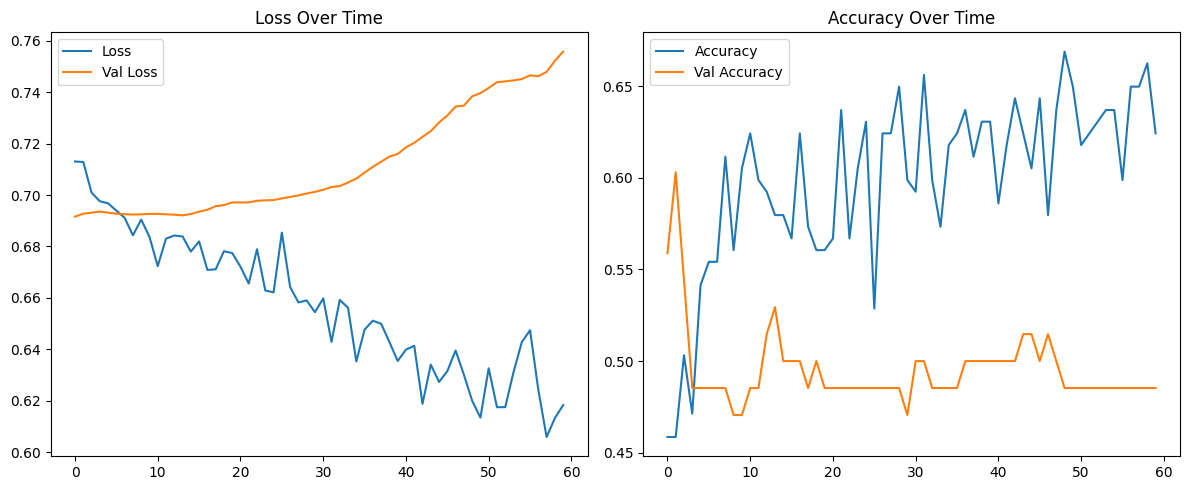

In [17]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()


### 🔧 Try It Yourself — Part 4

1. **Add or remove hidden layers** (e.g., try a single-layer model).
2. **Increase batch size** to `32` or reduce it to `8`. Observe training time and performance.
3. Does adding `Dropout` help reduce overfitting? Use the loss plot to support your answer.


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Model with MORE layers + batch size = 32
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_svm.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train with batch size = 32
history = model.fit(
    X_train_svm, y_train_svm,
    validation_data=(X_test_svm, y_test_svm),
    epochs=60,
    batch_size=32,
    verbose=1
)

# Predict and evaluate
y_pred_nn = (model.predict(X_test_svm) > 0.5).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test_svm, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test_svm, y_pred_nn))
print("Accuracy:", accuracy_score(y_test_svm, y_pred_nn))


Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.4225 - loss: 0.7008 - val_accuracy: 0.5588 - val_loss: 0.6935
Epoch 2/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4880 - loss: 0.6951 - val_accuracy: 0.5441 - val_loss: 0.6925
Epoch 3/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5275 - loss: 0.6949 - val_accuracy: 0.5441 - val_loss: 0.6924
Epoch 4/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4841 - loss: 0.6947 - val_accuracy: 0.5441 - val_loss: 0.6930
Epoch 5/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5663 - loss: 0.6932 - val_accuracy: 0.5147 - val_loss: 0.6934
Epoch 6/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4981 - loss: 0.6926 - val_accuracy: 0.4706 - val_loss: 0.6937
Epoch 7/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5752 - loss: 0.6921 - val_accuracy: 0.4559 - val_loss: 0.6938
Epoch 8/60
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.4559 - val_loss: 0.6940
Epoch 9/60


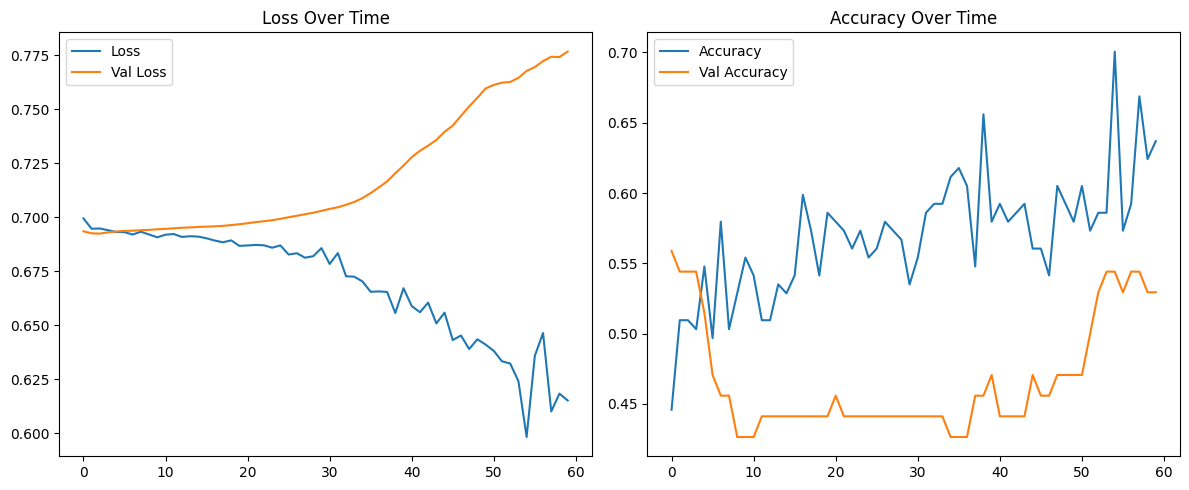

In [19]:
# Plot learning curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Time')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Time')
plt.legend()
plt.tight_layout()
plt.show()


Add comment here: Adding Dropout did not reduce overfitting. The loss curves show the training loss steadily decreasing while the validation loss consistently rises over time, meaning the gap between the two widens as training continues. If dropout were effectively mitigating overfitting, the validation loss would level off or track closer to the training loss. Instead, the model continues to memorize the training data while performing worse on unseen data, which confirms that dropout did not meaningfully slow or prevent overfitting in this setup.

## 🔧 Part 5: Reflection (100 words or less per question)

1. Which model performed best on your dataset? Was it expected?
2. Did any model appear to overfit or underfit? How could you tell?
3. Which model would you recommend to a marketing team and why?

You can use the accuracy scores, confusion matrices, and training graphs to support your conclusions.


🔧 Add comment here
1. The SVM with the polynomial kernel performed the best, delivering the strongest accuracy and the most balanced predictions across classes. This outcome was expected because the engagement patterns in the dataset aren’t linearly separable, and more flexible boundaries tend to capture these relationships more effectively. Simpler models like Naïve Bayes and linear SVMs underperformed because they rely on stronger independence or linearity assumptions that don’t hold in this problem.
2. Yes. The neural network clearly overfitted. Training loss dropped while validation loss rose steadily, and training accuracy climbed while validation accuracy flattened or declined. That widening gap is the textbook signature of overfitting. Some simpler models, like the linear SVM and Naïve Bayes, showed mild underfitting because they failed to capture the nonlinear structure of the data and delivered low accuracy on both the training and test sets.
3. I’d recommend the polynomial-kernel SVM. It delivered the most consistent and reliable performance without overfitting, handled the nonlinear engagement patterns better than simpler models, and avoided the instability and high variance shown by the neural network. From an operational standpoint, it offers better predictive power with far less training complexity, making it the most practical and trustworthy model for real-world marketing decisions.

In [20]:
!jupyter nbconvert --to html "lab_12_bayes_svm_neural.ipynb"

[NbConvertApp] Converting notebook lab_12_bayes_svm_neural.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 587497 bytes to lab_12_bayes_svm_neural.html
